# IMPORTS & DATASET

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

df = pd.read_csv("powerplant_data.csv")
# print(df.head())
# AT = Ambient Temperature
# V = Exhaust Vacuum
# AP = Ambient Pressure
# RH = Relative Humidity

X = df.drop("PE", axis=1)
y = df["PE"]

#split our data:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# SCALING:

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test) ##fit_transform

X_train_scaled ##dtype is float32
#y_train.values ##dtype is float64

array([[ 0.74805289,  0.72006931, -0.32660017, -0.49711722],
       [ 0.86181948,  1.26515721, -0.98521113,  0.8181501 ],
       [ 0.93409473,  1.52314975,  0.32523844,  0.80167494],
       ...,
       [-0.22097078, -0.834965  ,  0.36756563, -0.83554456],
       [ 0.94747903,  1.14245344, -0.41971997, -0.45455637],
       [-1.77355014, -1.19049131,  1.92520594,  0.91837402]])

# TENSORS:

In [ ]:
##data to tensors:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

# DATALOADERS:

In [ ]:
## accesses raw data form memory
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

## creats batches
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

# DEEP LEARNING:

### ANN MODEL:

In [ ]:
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
            # 1st Hidden Layer
            nn.Linear(X_train.shape[1], 6),#no_input,no_output
            nn.ReLU(),

            # 2nd Hiddden Layer
            nn.Linear(6, 6),
            nn.ReLU(),

            # Outpur
            nn.Linear(6, 1)
        )

    def forward(self, x):
        return self.model(x)

model = ANN()

### LOSS FN & OPTIMIZER:

In [ ]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

### TRAINING:

In [ ]:
## learnning of the model to get the correct weight and bias value:
train_losses = []
val_losses = []

best_val_loss = float("inf")

epochs = 100

for epoch in range(epochs):
    model.train()
    running_loss = 0.0 # tot training loss for 1 epoch

    for xb, yb in train_loader:
        # xb = features of 1 batch
        # yb = labels of 1 batch
        optimizer.zero_grad() # to not accumulate prev gradients and get fresh calc

        outputs = model(xb) # forward prop.....predicted outputs for this batch
        loss = criterion(outputs, yb) # compute loss
        loss.backward() # back prop... compute graddients
        optimizer.step() # params like weight and base got updated

        running_loss += loss.item() # loss is a tensor => py float

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    # Validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad(): # no gradient compute needed...so no autocompute
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = criterion(outputs, yb)
            ##no need of backward prop or optimizer in validation
            running_val_loss += loss.item()

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoc {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best.pt") # .pt or .pth

### gradually minimizing then stabilized at a pt....around 46 epoc....


epoc 1/100 ==> train loss = 205533.21822916667 & val loss = 203321.41796875
epoc 2/100 ==> train loss = 196336.037890625 & val loss = 185302.98567708334
epoc 3/100 ==> train loss = 166410.63294270833 & val loss = 142865.3890625
epoc 4/100 ==> train loss = 112902.68056640626 & val loss = 82961.69205729167
epoc 5/100 ==> train loss = 58997.220442708334 & val loss = 40406.27350260417
epoc 6/100 ==> train loss = 30686.41717122396 & val loss = 24263.542708333334
epoc 7/100 ==> train loss = 21062.479634602863 & val loss = 18491.713004557292
epoc 8/100 ==> train loss = 16699.93914794922 & val loss = 14716.371044921874
epoc 9/100 ==> train loss = 13068.751578776042 & val loss = 11005.228230794271
epoc 10/100 ==> train loss = 9409.845207214355 & val loss = 7629.267260742187
epoc 11/100 ==> train loss = 6329.121682739258 & val loss = 4921.575215657552
epoc 12/100 ==> train loss = 3939.6910354614256 & val loss = 3008.802451578776
epoc 13/100 ==> train loss = 2369.2664042154947 & val loss = 1809.5

### VISUALIZING LOSSES:

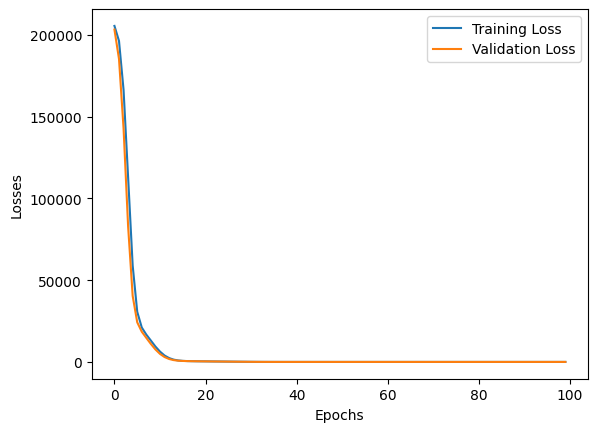

In [ ]:
loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": val_losses
})

plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")
plt.legend()

plt.show()


### LOADING THE BEST MODEL:

In [ ]:
##we will be minimizing validation data loss because it is being done on unseen data
#not like seen data for training
print(model.load_state_dict(torch.load("best.pt")))

<All keys matched successfully>


### EVALUATION:

In [ ]:
model.eval()
with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)

    train_mse_loss = criterion(train_preds, y_train_tensor)
    test_mse_loss = criterion(test_preds, y_test_tensor)

print("Training MSE: ", train_mse_loss.item())
print("Testing MSE: ", test_mse_loss.item())
print("r2 score: ", r2_score(y_test, test_preds))

Training MSE:  18.96669578552246
Testing MSE:  17.463003158569336
r2 score:  0.9389713093499086


### COMPARISON WITH ACTUAL DATA:

In [ ]:
predicted_df = pd.DataFrame(test_preds.numpy(), columns=["Predicted Values"])
actual_df = pd.DataFrame(y_test.values, columns=["Actual Values"])

print(pd.concat([predicted_df, actual_df], axis=1))

      Predicted Values  Actual Values
0           436.110535         433.27
1           436.244141         438.16
2           460.456879         458.42
3           476.546265         480.82
4           438.172729         441.41
...                ...            ...
1909        451.010925         456.70
1910        433.416199         438.04
1911        468.128235         467.80
1912        432.918976         437.14
1913        456.219513         456.78

[1914 rows x 2 columns]
